In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model
import seaborn as sns





In [46]:
df= pd.read_csv('/Users/David Danell/Desktop/jupyter notebook/data collections/hemnet_data_clean.csv')

df.info()
#df.describe()
#df.shape
#df.nunique()
print(df.isnull())

#df[df['rooms'].isna()]
df=df.dropna()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              500 non-null    float64
 1   address                 500 non-null    str    
 2   asked_price             500 non-null    float64
 3   coordinate              500 non-null    str    
 4   final_price             500 non-null    int64  
 5   pourcentage_difference  500 non-null    float64
 6   land_area               495 non-null    float64
 7   area                    499 non-null    float64
 8   commune                 500 non-null    str    
 9   price_per_area          499 non-null    float64
 10  rooms                   490 non-null    float64
 11  sale_date               500 non-null    str    
 12  supplemental_area       500 non-null    float64
dtypes: float64(8), int64(1), str(4)
memory usage: 50.9 KB
     Unnamed: 0  address  asked_price  coordinate  f

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'asked_price'}>,
        <Axes: title={'center': 'final_price'}>],
       [<Axes: title={'center': 'pourcentage_difference'}>,
        <Axes: title={'center': 'land_area'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'price_per_area'}>,
        <Axes: title={'center': 'rooms'}>,
        <Axes: title={'center': 'supplemental_area'}>]], dtype=object)

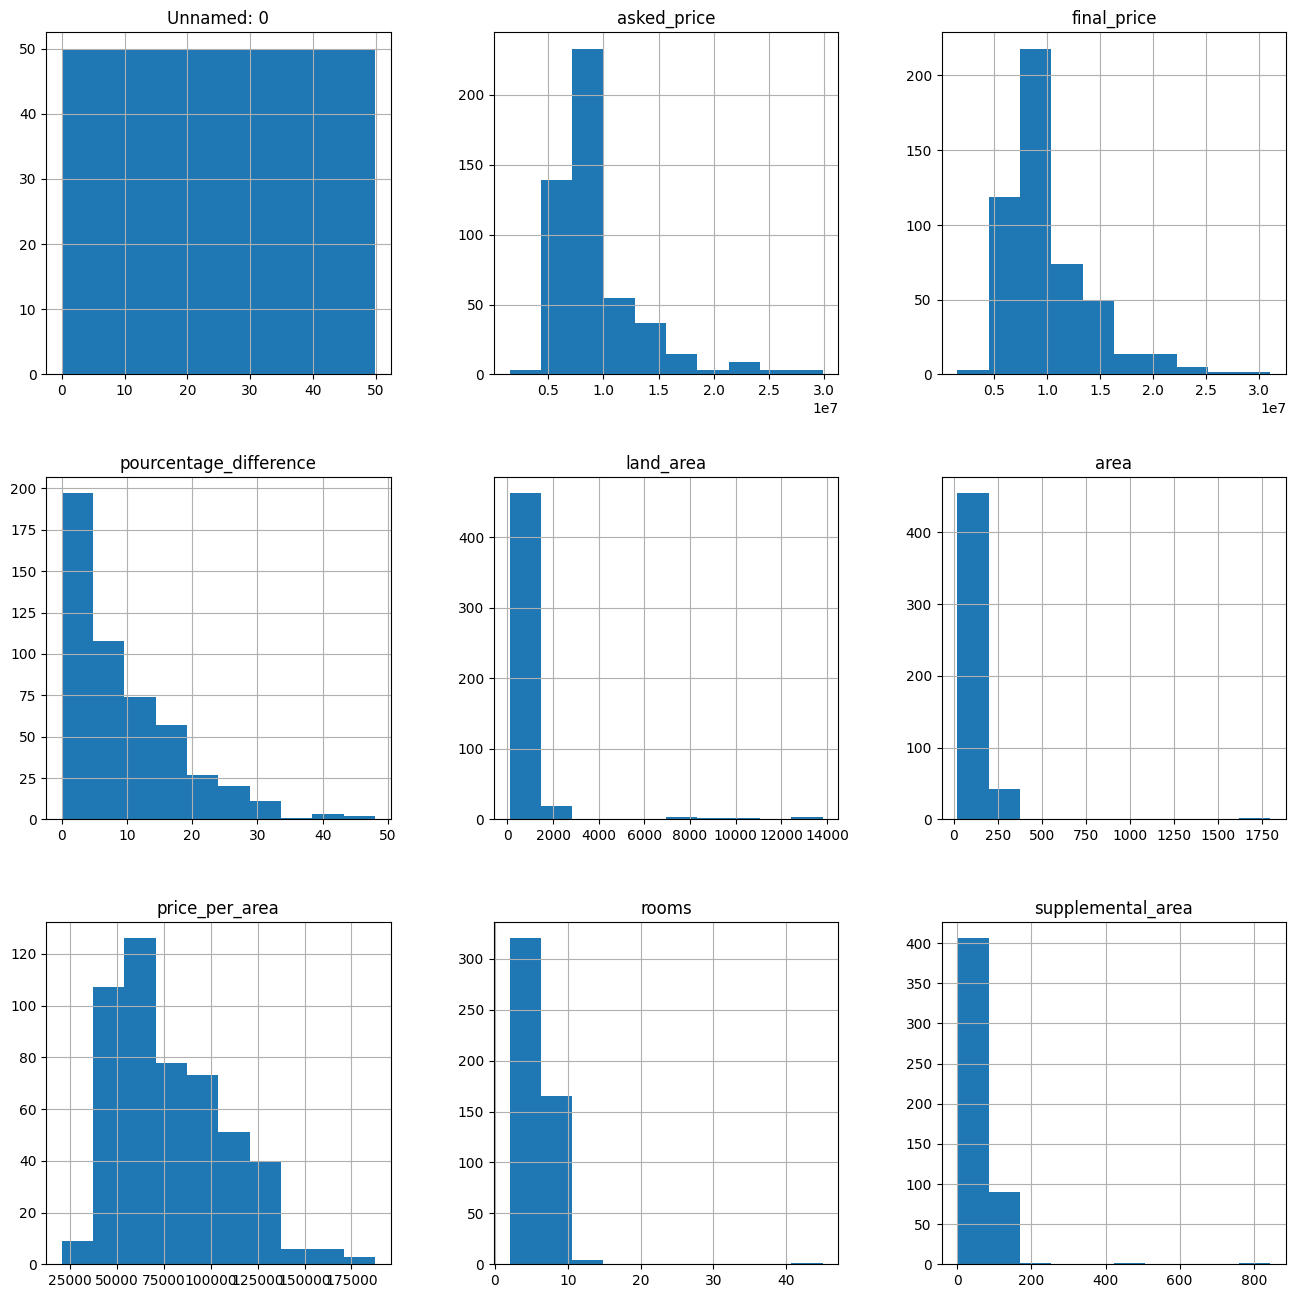

In [8]:
df.hist(figsize=(16,16))

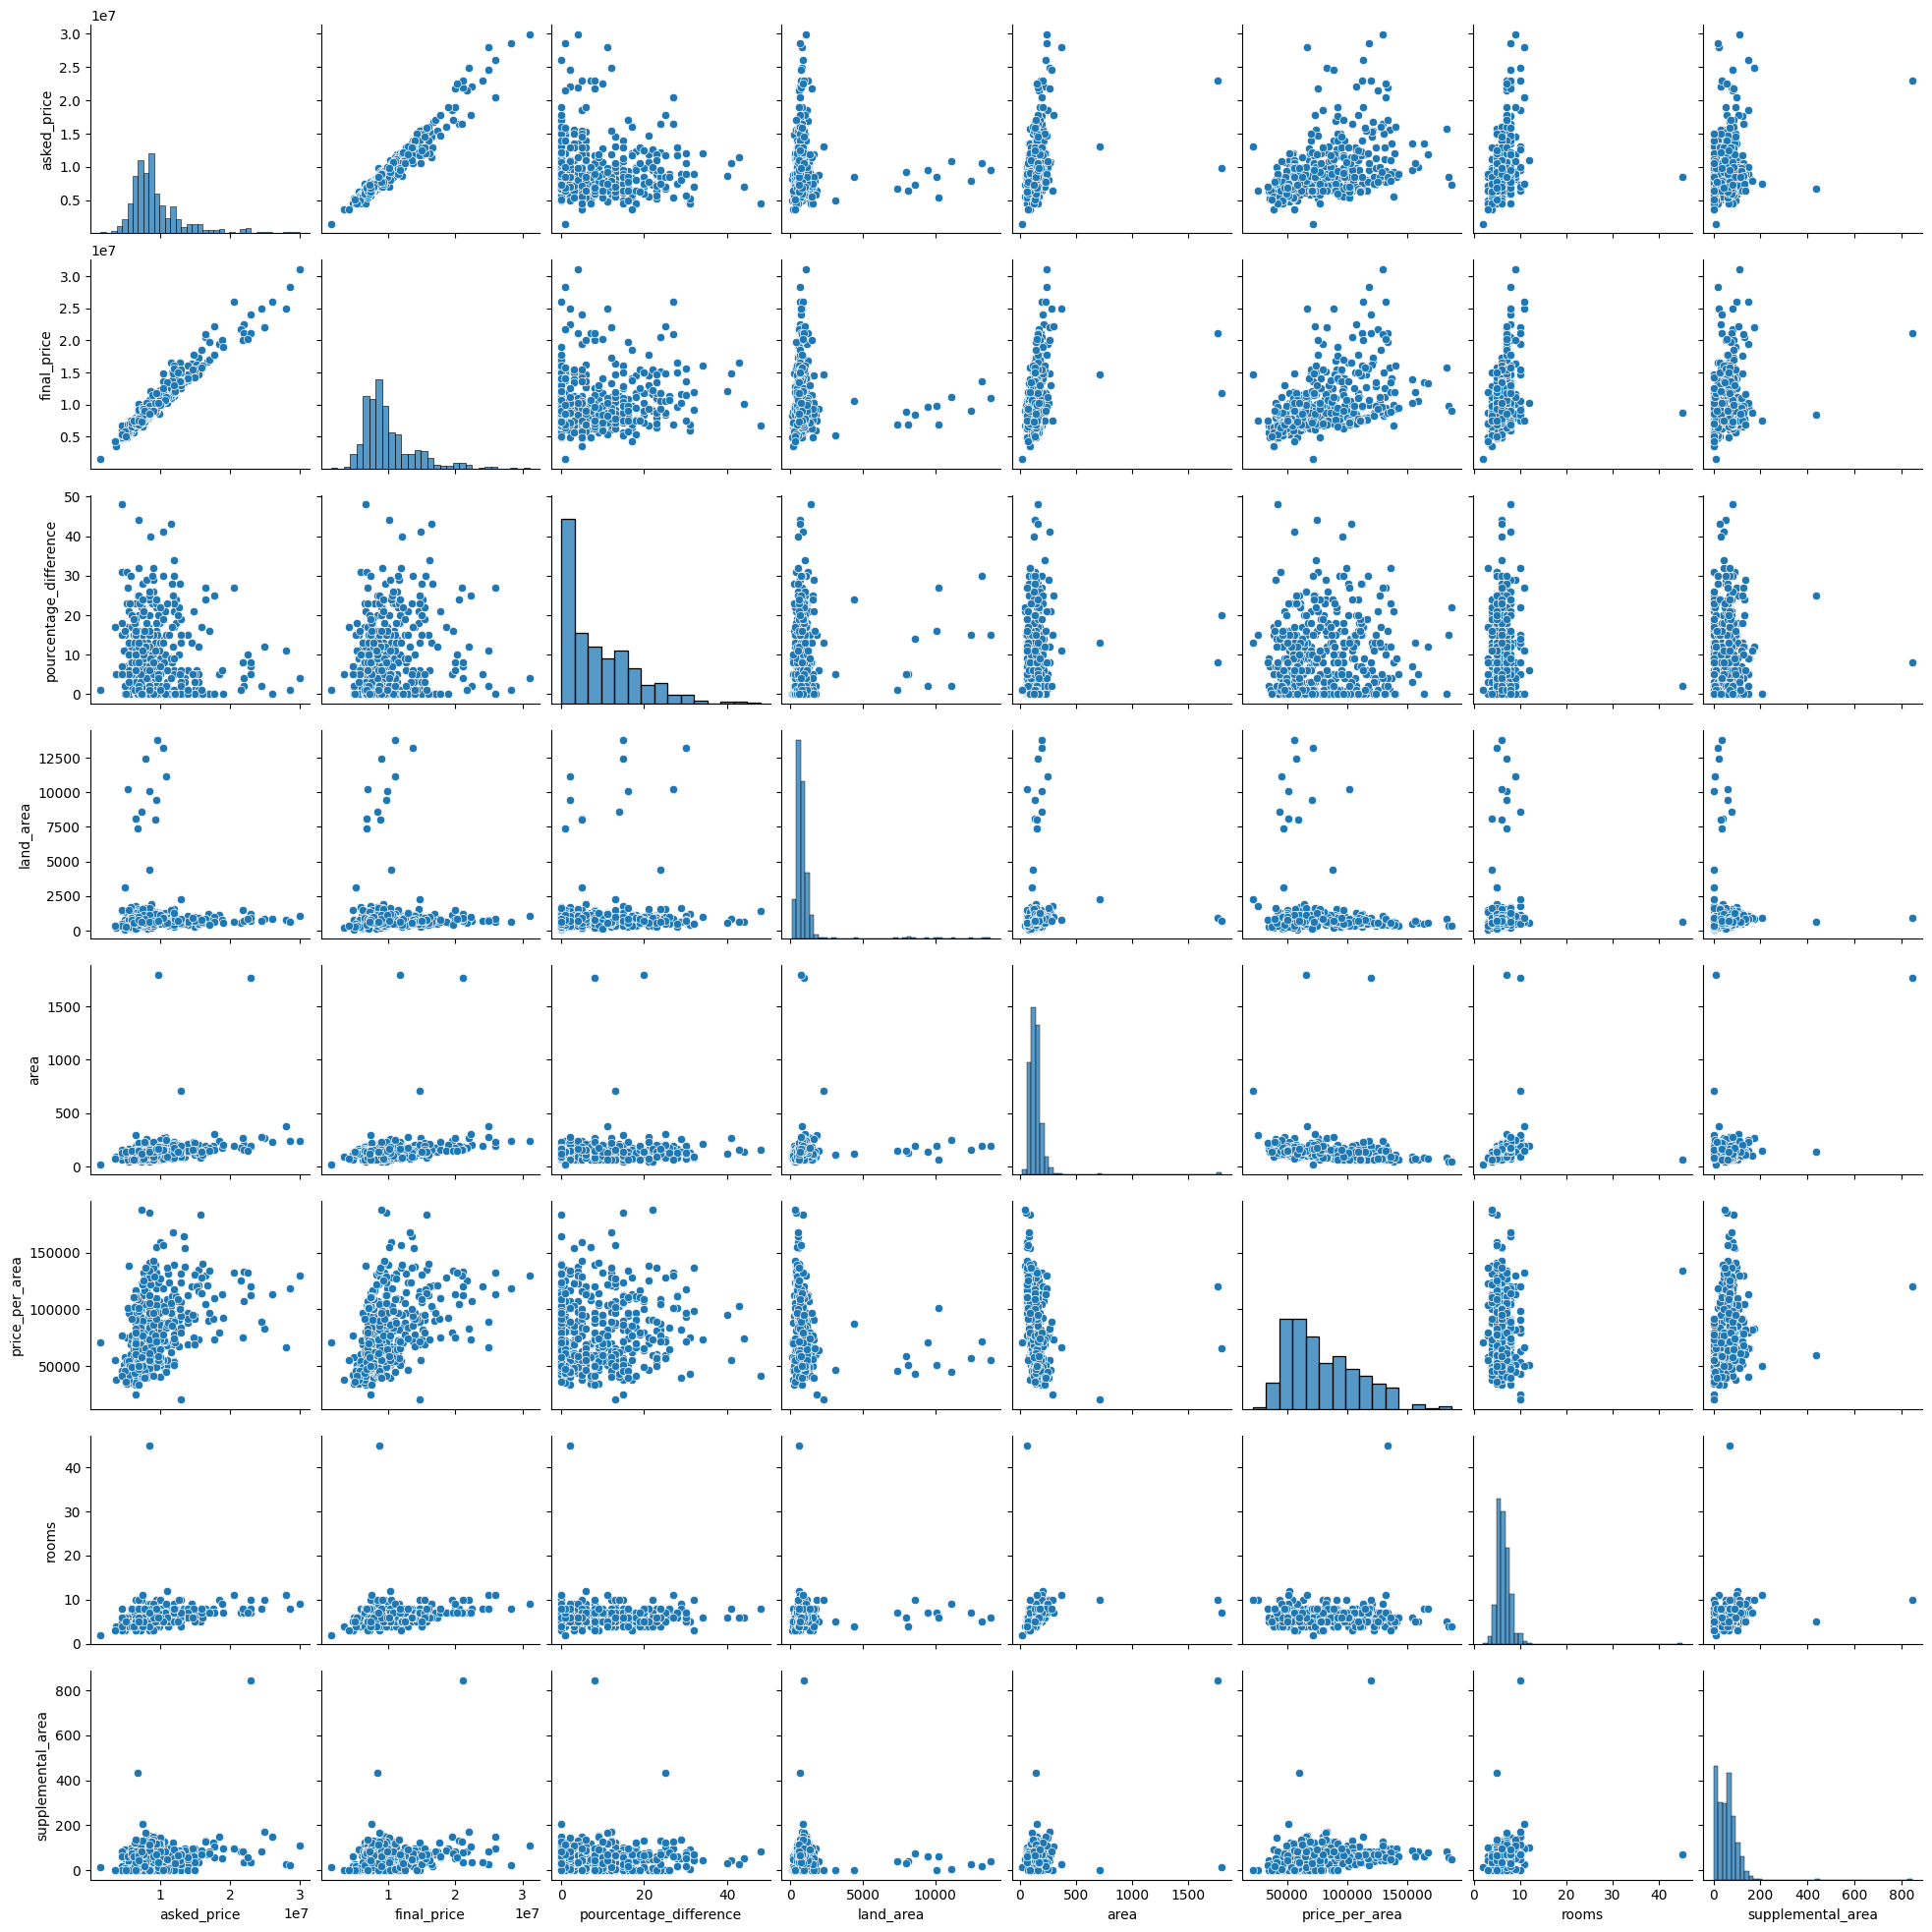

In [13]:
df.drop(columns=["Unnamed: 0"], inplace=True)

sns.pairplot(data=df )


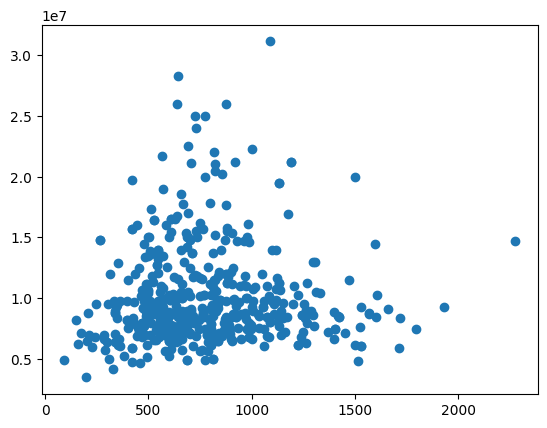

In [ ]:
tmp_df= df[df["land_area"]< 2500]

plt.scatter(tmp_df["land_area"], tmp_df["final_price"])

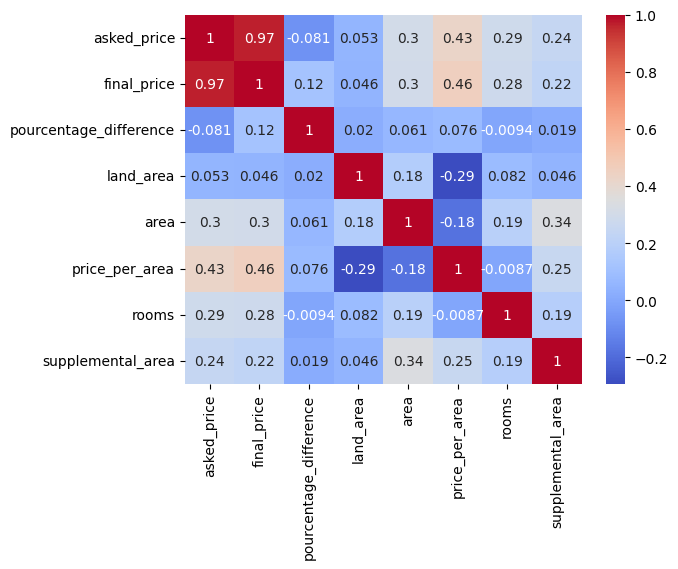

In [24]:

df_sub= tmp_df[['asked_price', 'final_price',
       'pourcentage_difference', 'land_area', 'area',
       'price_per_area', 'rooms', 'supplemental_area']]

df_sub_corr=df_sub.corr()

sns.heatmap(df_sub_corr, annot=True, cmap="coolwarm")
plt.show()

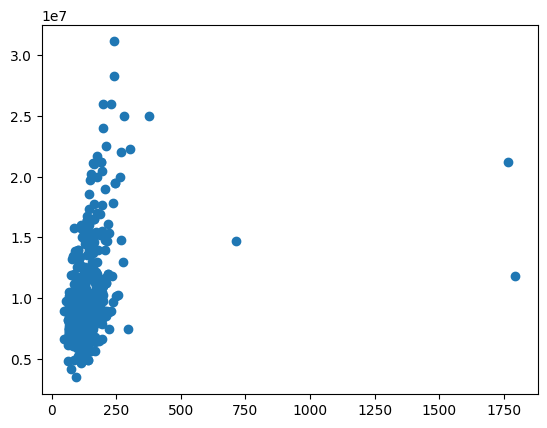

In [25]:
plt.scatter(tmp_df["area"], tmp_df["final_price"])

In [ ]:
y=df.final_price
features= [
       'asked_price',
       'pourcentage_difference',
       'land_area', 
       'area',
       'price_per_area', 
       'rooms', 
       'supplemental_area'
       ]

X=df[features]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=1)




In [61]:

from sklearn.linear_model import LinearRegression


modell= LinearRegression()

modell.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


290903.8887988542


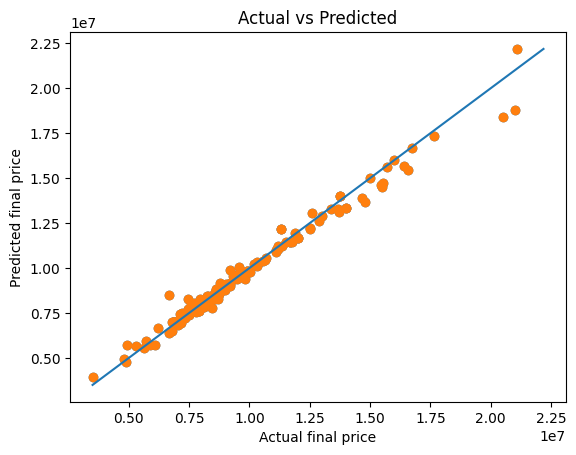

In [68]:
predictions=modell.predict(X_val)
print(mean_absolute_error(y_val, predictions))

plt.scatter(y_val, predictions)
plt.scatter(y_val, predictions)

min_val = min(y_val.min(), predictions.min())
max_val = max(y_val.max(), predictions.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual final price")
plt.ylabel("Predicted final price")
plt.title("Actual vs Predicted")
plt.show()